# Imports

In [6]:
import pandas as pd
# import ast
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 500)

# Reading in the raw data

In [9]:
df_raw = pd.read_csv("../data/raw/ChestX-ray14/Data_Entry_2017.csv")
df_raw = df_raw.drop(columns="Unnamed: 11")

In [10]:
df_raw.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [12]:
df_raw["Patient ID"].nunique()

30805

In [13]:
df_raw.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


In [14]:
view_counts = df_raw["Finding Labels"].value_counts()
view_counts[:20]

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64

# Plotting the data

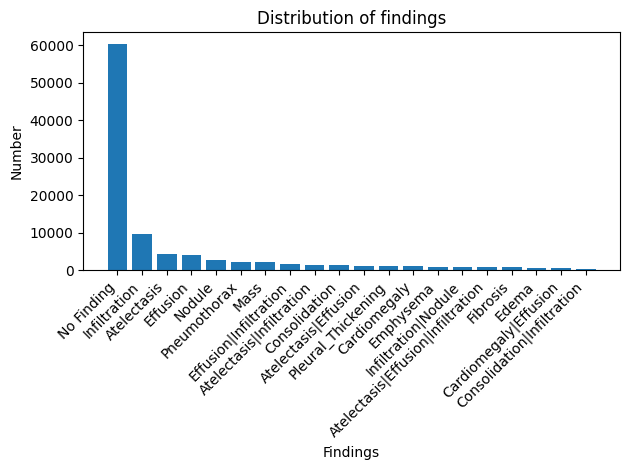

In [15]:
plt.figure()
view_counts = df_raw["Finding Labels"].value_counts()
plt.bar(view_counts[:20].index, view_counts[:20].values)
plt.title("Distribution of findings")
plt.xlabel("Findings")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
label_sex_crosstab = (df_raw.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_crosstab[:5]

Patient Gender,F,M
Finding Labels,,
No Finding,26439,33922
Infiltration,4164,5383
Effusion,1797,2158
Atelectasis,1612,2603
Pneumothorax,1193,1001


<Figure size 640x480 with 0 Axes>

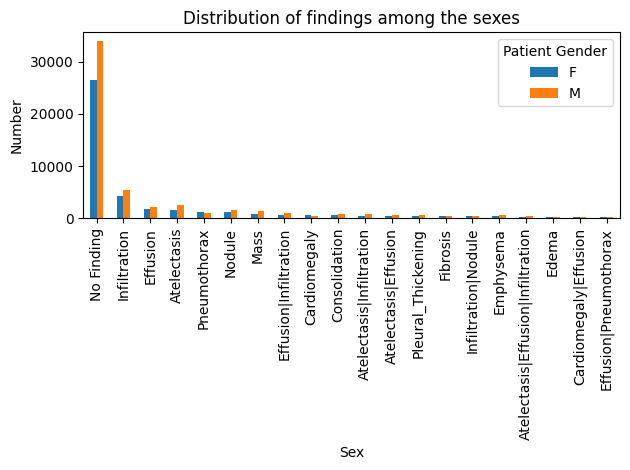

In [17]:
plt.figure()

label_sex_crosstab[:20].plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

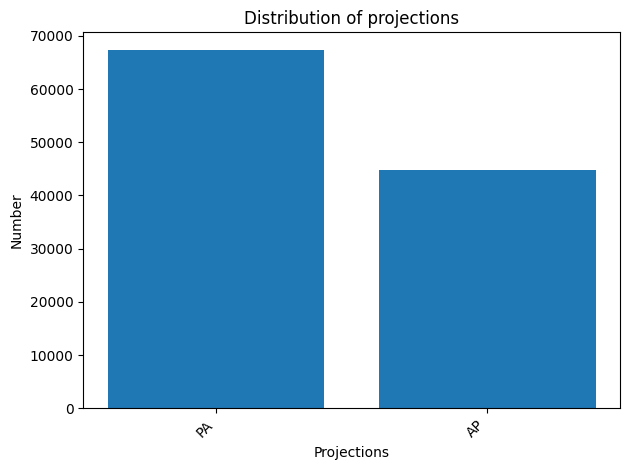

In [18]:
plt.figure()
view_counts = df_raw["View Position"].value_counts()
plt.bar(view_counts[:10].index, view_counts[:10].values)
plt.title("Distribution of projections")
plt.xlabel("Projections")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Reading in the processed data, and the drain data

In [22]:
df_drains_pos = pd.read_csv("../data/raw/ChestX-ray14/NIH-CX14_TubeAnnotations_NonExperts_aggregated.csv", index_col=0)
df_drains_neg = pd.read_csv("../data/processed/ChestX-ray14/CXR14_Drains_Labels.csv", sep=";", index_col=0)
df_processed = pd.read_csv("../data/processed/ChestX-ray14/processed_labels.csv", index_col=0)

In [23]:
df_processed["Image Index"].nunique()

25596

In [24]:
df_drains_pos["Image Index"].nunique()

3543

In [25]:
df_drains_pos.head()

,Image Index,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain
0,00011831_003.png,1.0,R,1.0,R,1
1,00014014_009.png,0.0,NaN,0.0,NaN,0
2,00030137_003.png,1.0,L,1.0,L,1
3,00018366_038.png,1.0,L,1.0,L,1
4,00014251_003.png,1.0,R,1.0,R,1


In [26]:
df_drains_pos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3543 entries, 0 to 3708
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Image Index        3543 non-null   object 
 1   Drain_a1           3543 non-null   float64
 2   Drain_Location_a1  1671 non-null   object 
 3   Drain_a2           3543 non-null   float64
 4   Drain_Location_a2  1669 non-null   object 
 5   Drain              3543 non-null   int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 193.8+ KB


In [27]:
df_drains_neg.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Unnamed: 0,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,143.0,143.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,143.0,143.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False


In [28]:
df_drains_neg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25596 entries, 0 to 25595
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  25596 non-null  object 
 1   Finding Labels               25596 non-null  object 
 2   Follow-up #                  25596 non-null  int64  
 3   Patient ID                   25596 non-null  int64  
 4   Patient Age                  25596 non-null  int64  
 5   Patient Gender               25596 non-null  object 
 6   View Position                25596 non-null  object 
 7   OriginalImage[Width          25596 non-null  int64  
 8   Height]                      25596 non-null  int64  
 9   OriginalImagePixelSpacing[x  25596 non-null  float64
 10  y]                           25596 non-null  float64
 11  Unnamed: 11                  0 non-null      float64
 12  Unnamed: 0                   1760 non-null   float64
 13  Drain_a1             

In [29]:
df_processed["Drain"].value_counts()

Drain
-1.0    23836
 1.0     1021
 0.0      739
Name: count, dtype: int64

In [30]:
df_processed.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Unnamed: 0,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,False
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,False
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,False
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,False
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,False


In [31]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25596 entries, 0 to 25595
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  25596 non-null  object 
 1   Finding Labels               25596 non-null  object 
 2   Follow-up #                  25596 non-null  int64  
 3   Patient ID                   25596 non-null  int64  
 4   Patient Age                  25596 non-null  int64  
 5   Patient Gender               25596 non-null  object 
 6   View Position                25596 non-null  object 
 7   OriginalImage[Width          25596 non-null  int64  
 8   Height]                      25596 non-null  int64  
 9   OriginalImagePixelSpacing[x  25596 non-null  float64
 10  y]                           25596 non-null  float64
 11  Unnamed: 11                  0 non-null      float64
 12  Unnamed: 0                   1760 non-null   float64
 13  Drain_a1             

# Cleaning `df_drains_neg`

### We will use `df_drains_neg` as that is the one that contains all the necessary data
Such as the drain annotations for the positive AND negative cases of pneumothorax

In [32]:
df_drains_neg = df_drains_neg.drop(columns=["Unnamed: 11", "Unnamed: 0"])
df_drains_neg

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25591,00030800_000.png,No Finding,0,30800,34,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
25592,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
25593,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
25594,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False


## Sanity checking the dataset

In [33]:
print(df_drains_neg["Image Index"].nunique())
print(df_drains_neg["Patient ID"].nunique())

25596
2797


In [34]:
df_drains_neg.sort_values(by="Follow-up #", ascending=False)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6428,00010007_183.png,Effusion|Infiltration,183,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6427,00010007_182.png,Consolidation,182,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,1.0,False
6426,00010007_181.png,No Finding,181,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6425,00010007_180.png,Infiltration|Pleural_Thickening,180,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6424,00010007_179.png,Atelectasis|Effusion,179,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22180,00028309_000.png,No Finding,0,28309,21,M,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False
22181,00028310_000.png,No Finding,0,28310,62,M,PA,2992,2991,143.000000,143.000000,NaN,NaN,NaN,NaN,1.0,False
22182,00028311_000.png,No Finding,0,28311,32,F,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
22183,00028312_000.png,No Finding,0,28312,59,F,PA,1843,1826,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False


In [35]:
df_drains_neg[(df_drains_neg["Patient ID"] == 10007) & (df_drains_neg["Pneumothorax"] == False)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6245,00010007_000.png,No Finding,0,10007,57,M,PA,2992,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
6246,00010007_001.png,No Finding,1,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
6247,00010007_002.png,Infiltration,2,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
6248,00010007_003.png,Edema,3,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,False
6249,00010007_004.png,Edema|Effusion|Infiltration,4,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6424,00010007_179.png,Atelectasis|Effusion,179,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
6425,00010007_180.png,Infiltration|Pleural_Thickening,180,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
6426,00010007_181.png,No Finding,181,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
6427,00010007_182.png,Consolidation,182,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,False


In [36]:
print(df_drains_neg["Patient Age"].describe())
print(df_drains_neg[df_drains_neg["Patient Age"] == 0].shape[0])
print(df_drains_neg[df_drains_neg["Patient Age"] > 100].shape[0])

count    25596.000000
mean        47.007579
std         16.854982
min          1.000000
25%         34.000000
50%         49.000000
75%         59.000000
max        414.000000
Name: Patient Age, dtype: float64
0
4


In [37]:
df_raw.sort_values(by="Patient Age", ascending=False).head(20)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
86264,00021275_003.png,No Finding,3,21275,413,F,AP,3056,2544,0.139,0.139
91369,00022811_000.png,No Finding,0,22811,412,M,PA,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
101194,00026871_000.png,No Finding,0,26871,155,F,PA,2992,2991,0.143,0.143
104590,00027989_000.png,No Finding,0,27989,155,M,PA,2992,2991,0.143,0.143
98495,00026028_001.png,Atelectasis,1,26028,154,M,PA,2992,2991,0.143,0.143
95794,00025206_000.png,Infiltration|Mass,0,25206,153,M,PA,2992,2991,0.143,0.143


In [38]:
df_raw[df_raw["Patient Age"] > 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


In [39]:
df_drains_neg[df_drains_neg["Patient Age"] > 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
3488,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
8167,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
15610,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,143.0,143.0,1.0,L,1.0,L,1.0,True
17950,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,0.0,False


In [40]:
df_drains_neg[(df_drains_neg["Finding Labels"] == "No Finding") & (df_drains_neg["Drain"] == 1.0)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
16,00000013_008.png,No Finding,8,13,60,M,AP,3056,2544,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
22,00000013_014.png,No Finding,14,13,61,M,PA,2021,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
24,00000013_016.png,No Finding,16,13,61,M,PA,1725,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
46,00000013_038.png,No Finding,38,13,56,M,PA,2822,2861,143.000000,143.000000,NaN,NaN,NaN,NaN,1.0,False
57,00000032_002.png,No Finding,2,32,55,F,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25585,00030792_001.png,No Finding,1,30792,10,F,PA,1663,1675,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
25586,00030794_000.png,No Finding,0,30794,38,F,PA,2021,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
25587,00030796_000.png,No Finding,0,30796,44,M,PA,2021,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
25588,00030797_000.png,No Finding,0,30797,24,M,PA,2021,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False


In [41]:
print(df_raw["Patient Age"].describe())
print(df_raw[df_raw["Patient Age"] == 0].shape[0])
print(df_raw[df_raw["Patient Age"] > 100].shape[0])
df_raw[df_raw["Patient Age"] > 100]

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64
0
16


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


# Removing patients with age > 100 from `df_drains_neg`

In [42]:
df_drains_neg = df_drains_neg[~(df_drains_neg["Patient Age"] > 100)]

In [43]:
df_drains_neg[df_drains_neg["Patient Age"] > 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax


In [44]:
all_labels = df_drains_neg["Finding Labels"].str.split("|").explode()
label_counts = all_labels.value_counts()
print(label_counts)

Finding Labels
No Finding            9861
Infiltration          6112
Effusion              4657
Atelectasis           3279
Pneumothorax          2664
Consolidation         1815
Mass                  1747
Nodule                1623
Pleural_Thickening    1142
Emphysema             1093
Cardiomegaly          1069
Edema                  924
Pneumonia              554
Fibrosis               435
Hernia                  86
Name: count, dtype: int64


In [45]:
contradictions = df_drains_neg[df_drains_neg["Finding Labels"].str.contains("No Finding") & 
                               df_drains_neg["Finding Labels"].str.contains("\|")]
print(f"contradicting labels ('No Finding' + a disease): {len(contradictions)}")

contradicting labels ('No Finding' + a disease): 0


# Plotting the data

In [46]:
drains_pivot = (df_drains_neg.explode("Drain").pivot_table(index="Drain", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
drains_pivot

Patient Gender,F,M
Drain,,
0.0,5577,7832
1.0,5136,7047


<Figure size 640x480 with 0 Axes>

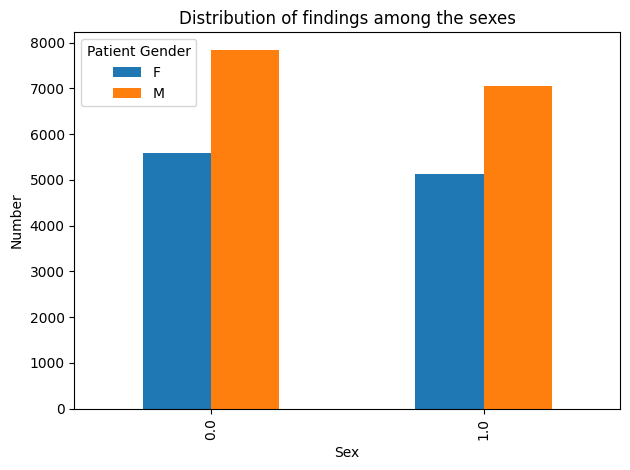

In [47]:
plt.figure()

drains_pivot.plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

       OriginalImage[Width       Height]
count         25592.000000  25592.000000
mean           2660.564239   2423.300172
std             354.394944    385.423313
min            1189.000000   1178.000000
25%            2500.000000   2048.000000
50%            2502.000000   2533.000000
75%            2992.000000   2665.000000
max            3827.000000   4715.000000


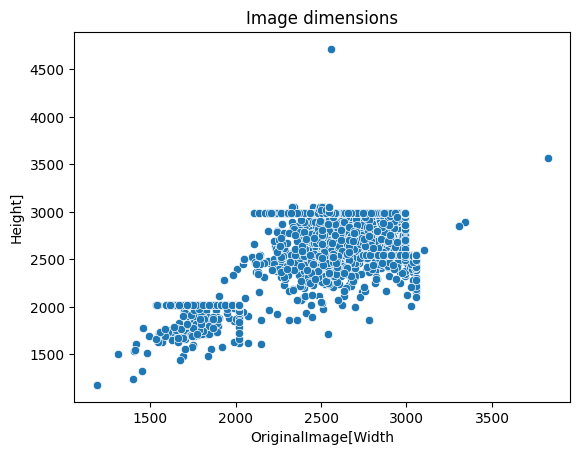

       OriginalImagePixelSpacing[x            y]
count                 25592.000000  25592.000000
mean                    137.758531    137.758531
std                      46.858240     46.858240
min                       0.193754      0.193754
25%                     139.000000    139.000000
50%                     143.000000    143.000000
75%                     168.000000    168.000000
max                     171.000000    171.000000
Asymmetric pixel spacing: 0


In [48]:
print(df_drains_neg[["OriginalImage[Width", "Height]"]].describe())
sns.scatterplot(data=df_drains_neg, x="OriginalImage[Width", y="Height]")
plt.title("Image dimensions")
plt.show()

print(df_drains_neg[["OriginalImagePixelSpacing[x", "y]"]].describe())
# finding mismatches between pixels
mismatch = df_drains_neg[df_drains_neg["OriginalImagePixelSpacing[x"] != df_drains_neg["y]"]]
print(f"Asymmetric pixel spacing: {len(mismatch)}")

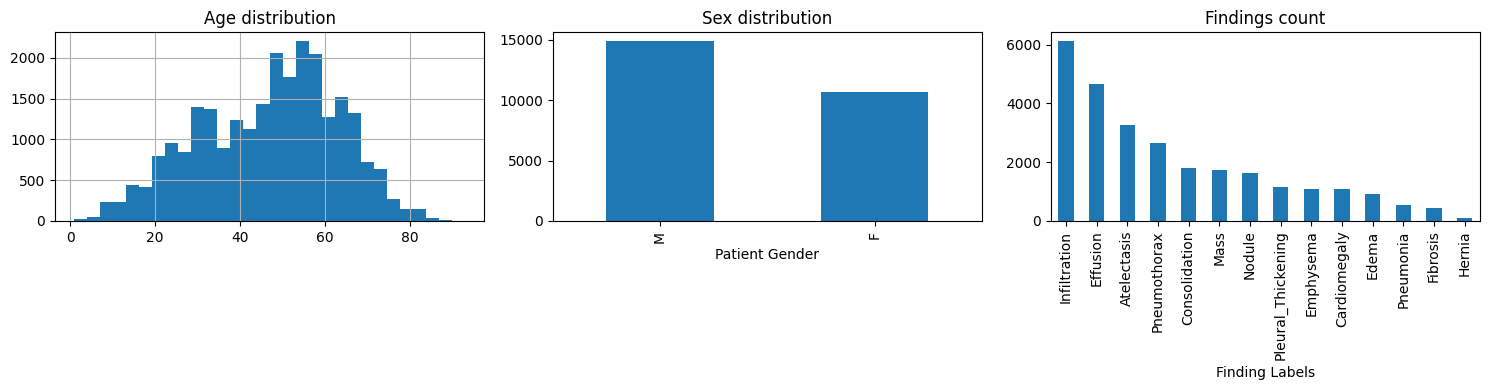

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_drains_neg["Patient Age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Age distribution")

df_drains_neg["Patient Gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex distribution")

label_counts.drop("No Finding", errors="ignore").plot(kind="bar", ax=axes[2])
axes[2].set_title("Findings count")

plt.tight_layout()
plt.show()

In [50]:
df_drains_neg.sort_values(by="Patient Age")

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6617,00010230_000.png,No Finding,0,10230,1,M,AP,2048,2500,115.000000,115.000000,NaN,NaN,NaN,NaN,0.0,False
12147,00015007_001.png,No Finding,1,15007,2,F,PA,1670,1769,143.000000,143.000000,NaN,NaN,NaN,NaN,0.0,False
24013,00029627_000.png,No Finding,0,29627,2,M,AP,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False
6618,00010230_001.png,Infiltration,1,10230,2,M,AP,2048,2500,115.000000,115.000000,NaN,NaN,NaN,NaN,0.0,False
23324,00029093_000.png,No Finding,0,29093,3,M,AP,1189,1178,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,00000732_009.png,Effusion,9,732,87,F,PA,2596,2639,143.000000,143.000000,NaN,NaN,NaN,NaN,0.0,False
23443,00029188_001.png,Hernia,1,29188,88,F,PA,2015,2021,0.194311,0.194311,NaN,NaN,NaN,NaN,1.0,False
23442,00029188_000.png,No Finding,0,29188,88,F,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
23659,00029391_000.png,Cardiomegaly,0,29391,91,F,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False


In [51]:
df_drains_neg["Patient ID"].value_counts()

Patient ID
10007    184
13670    173
15530    158
12834    157
13993    143
        ... 
29010      1
29008      1
29004      1
29003      1
30805      1
Name: count, Length: 2797, dtype: int64

In [52]:
df_drains_neg["Patient ID"].nunique()

2797

In [53]:
findings_pivot = (df_drains_neg.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
findings_pivot[:100]

Patient Gender,F,M
Finding Labels,,
No Finding,4151,5710
Infiltration,887,1333
Effusion,477,690
Pneumothorax,454,498
Atelectasis,338,463
...,...,...
Consolidation|Fibrosis,7,7
Atelectasis|Edema,7,5
Mass|Pleural_Thickening|Pneumothorax,7,2


<Figure size 640x480 with 0 Axes>

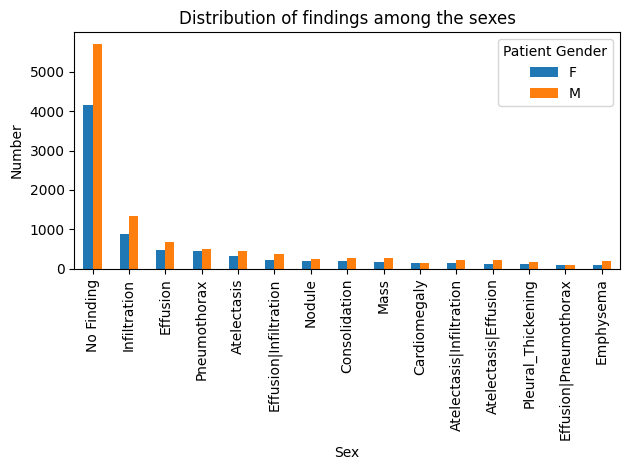

In [54]:
plt.figure()

findings_pivot[:15].plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()